In [1]:
import os
import pickle
import matplotlib.pyplot as plt
from lib.algorithms import PathFormulation, Objective, PathFormulationCVXPY, PathFormulationALCD
from lib.traffic_matrix import *
from lib.problem import Problem
num_paths, edge_disjoint, dist_metric = (4, True, "min-hop")

In [2]:
# create sample problem
topo_fname = "/home/sauce/teal/topologies/UsCarrier.json"
tm_fname = "/home/sauce/teal/traffic-matrices/toy/UsCarrier.json_toy_28_1.0_traffic-matrix.pkl"
topo_name = "UsCarrier"
# topo_fname = "/home/sauce/teal/topologies/Kdl.json"
# tm_fname = "/home/sauce/teal/traffic-matrices/toy/Kdl.json_toy_28_1.0_traffic-matrix.pkl"
# topo_name = "Kdl"
# topo_fname = "/home/sauce/teal/topologies/ASN2k.json"
# tm_fname = "/home/sauce/teal/traffic-matrices/toy/ASN2k.json_toy_28_1.0_traffic-matrix.pkl"
# topo_name = "ASN2k"
problem = Problem.from_file(topo_fname, tm_fname)
traffic_seed = problem.traffic_matrix.seed
total_demand = problem.total_demand
print("traffic seed: {}".format(traffic_seed))
print("traffic scale factor: {}".format(problem.traffic_matrix.scale_factor))
print("traffic matrix model: {}".format(problem.traffic_matrix.model))
print(f"traffic matrix class: {problem.traffic_matrix.__class__.__name__}")
print(f"# commodities: {len(problem.commodity_list)}")
print("total demand: {}".format(total_demand))

Invalidating commodity lists..
traffic seed: 0
traffic scale factor: 1.0
traffic matrix model: real
traffic matrix class: RealTrafficMatrix
Generating commodity list ...
# commodities: 24806
total demand: 24964.0


In [3]:
log = open("/tmp/path_formulation.txt", "w")
state = {}
pf = PathFormulationALCD(objective=Objective.get_obj_from_str("total_flow"), num_paths=num_paths,
                              edge_disjoint=edge_disjoint, dist_metric=dist_metric,out=log, VERBOSE=True)
ret, state = pf.solve(problem, state=state)
# pf_sol_dict = pf.sol_dict

Loading paths from pickle file /home/sauce/teal/pop-ncflow-lptop/../topologies/paths/path-form/Kdl.json-4-paths_edge-disjoint-True_dist-metric-min-hop-dict.pkl
paths_dict size: 567762
# Paths: 1064266
# Edges: 1790
# Commodities: 567762
ALCD Constraint matrix: 569552 inequalities, 0 equalities, 30711354 non-zero entries
ALCD Variables: 1064266 non-basic, 0 free
Initalizing ALCD solver
Solving using ALCD solver
ALCD solver stats: {'primal_obj_progress': [152131488.0, 557053.5625, 542432.9375, 543857.3125, 542847.375, 542560.0, 542495.0, 542453.8125, 542473.625, 542475.25, 542430.875, 542417.375, 542418.5, 542405.1875, 542403.5625, 542407.0, 542396.8125, 542405.3125, 542394.875, 542396.25, 542397.1875, 542411.0625, 542406.6875, 542404.5, 542400.8125, 542400.0, 542406.3125, 542401.5, 542399.625, 542405.3125, 542399.6875, 542400.5625, 542399.4375, 542401.1875, 542400.0, 542397.375, 542399.5, 542398.5, 542403.6875, 542394.625, 542401.5, 542398.5625, 542398.3125, 542395.4375, 542404.4375, 54

In [4]:
# update the problem with a 10% change
problem.update_traffic_matrix(1, "uniform", alpha=0.1)
traffic_seed = problem.traffic_matrix.seed
total_demand = problem.total_demand
print(f"# commodities: {len(problem.commodity_list)}")
print("traffic seed: {}".format(traffic_seed))
print("traffic scale factor: {}".format(problem.traffic_matrix.scale_factor))
print("traffic matrix model: {}".format(problem.traffic_matrix.model))
print("total demand: {}".format(total_demand))

Perturbing traffic matrix with uniform distribution: alpha: 0.1
Invalidating commodity lists..
Generating commodity list ...
# commodities: 567762
traffic seed: 28
traffic scale factor: 1.0
traffic matrix model: real
total demand: 568497.5623957011


In [5]:
pf = PathFormulationALCD(objective=Objective.get_obj_from_str("total_flow"), num_paths=num_paths,
                              edge_disjoint=edge_disjoint, dist_metric=dist_metric,out=log, VERBOSE=True)
ret, state = pf.solve(problem, state=state)
# pf_sol_dict = pf.sol_dict

Loading paths from pickle file /home/sauce/teal/pop-ncflow-lptop/../topologies/paths/path-form/Kdl.json-4-paths_edge-disjoint-True_dist-metric-min-hop-dict.pkl
paths_dict size: 567762
# Paths: 1064266
# Edges: 1790
# Commodities: 567762
ALCD Constraint matrix: 569552 inequalities, 0 equalities, 0 non-zero entries
ALCD Variables: 1064266 non-basic, 0 free
Re-using Amat from previous run...
Initalizing ALCD solver
Initializing x0 from previous run
Initializing w0 from previous run
Solving using ALCD solver
ALCD solver stats: {'primal_obj_progress': [544466.0, 542329.5625, 542359.5, 542354.375, 542354.375], 'primal_inf_progress': [0.09999414575349919, 0.009307180473611232, 0.0015618230630920714, 0.0003035066143771692, 4.0033091397440046e-08], 'dual_inf_progress': [189.559336306178, 32.0754867427313, 1.250382011149668, 0.3710360073864649, 0.0034549728625279386], 'duality_gap_progress': [2415.820649281144, 70.2316335485084, 3.0425985681358725, 0.2782168622361496, 0.513521182583645], 'time_p

In [6]:
# update the problem with a 10% change
problem.update_traffic_matrix(1, "uniform", alpha=0.1)
traffic_seed = problem.traffic_matrix.seed
total_demand = problem.total_demand
print(f"# commodities: {len(problem.commodity_list)}")
print("traffic seed: {}".format(traffic_seed))
print("traffic scale factor: {}".format(problem.traffic_matrix.scale_factor))
print("traffic matrix model: {}".format(problem.traffic_matrix.model))
print("total demand: {}".format(total_demand))

Perturbing traffic matrix with uniform distribution: alpha: 0.1
Invalidating commodity lists..
Generating commodity list ...
# commodities: 567762
traffic seed: 28
traffic scale factor: 1.0
traffic matrix model: real
total demand: 568503.3641166448


In [7]:
pf = PathFormulationALCD(objective=Objective.get_obj_from_str("total_flow"), num_paths=num_paths,
                              edge_disjoint=edge_disjoint, dist_metric=dist_metric,out=log, VERBOSE=True)
ret, state = pf.solve(problem, state=state)
# pf_sol_dict = pf.sol_dict

Loading paths from pickle file /home/sauce/teal/pop-ncflow-lptop/../topologies/paths/path-form/Kdl.json-4-paths_edge-disjoint-True_dist-metric-min-hop-dict.pkl
paths_dict size: 567762
# Paths: 1064266
# Edges: 1790
# Commodities: 567762
ALCD Constraint matrix: 569552 inequalities, 0 equalities, 0 non-zero entries
ALCD Variables: 1064266 non-basic, 0 free
Re-using Amat from previous run...
Initalizing ALCD solver
Initializing x0 from previous run
Initializing w0 from previous run
Solving using ALCD solver
ALCD solver stats: {'primal_obj_progress': [543554.1875, 542276.25, 542372.375, 542350.25], 'primal_inf_progress': [0.10893677030019155, 0.012458669278543777, 0.01453037075693564, 0.014875911147774756], 'dual_inf_progress': [119.03181117412169, 61.49677614649772, 10.516818248754134, 0.0025829439437075052], 'duality_gap_progress': [1569.7739933889825, 164.25519646843895, 17.955333504010923, 0.5193781299749389], 'time_progress': [1.01097966, 3.01819194, 4.720940867, 6.320195843], 'iter_p

In [8]:
# update the problem with a 10% change
problem.update_traffic_matrix(1, "uniform", alpha=0.1)
traffic_seed = problem.traffic_matrix.seed
total_demand = problem.total_demand
print(f"# commodities: {len(problem.commodity_list)}")
print("traffic seed: {}".format(traffic_seed))
print("traffic scale factor: {}".format(problem.traffic_matrix.scale_factor))
print("traffic matrix model: {}".format(problem.traffic_matrix.model))
print("total demand: {}".format(total_demand))

Perturbing traffic matrix with uniform distribution: alpha: 0.1
Invalidating commodity lists..
Generating commodity list ...
# commodities: 567762
traffic seed: 28
traffic scale factor: 1.0
traffic matrix model: real
total demand: 568592.1723026881


In [9]:
pf = PathFormulationALCD(objective=Objective.get_obj_from_str("total_flow"), num_paths=num_paths,
                              edge_disjoint=edge_disjoint, dist_metric=dist_metric,out=log, VERBOSE=True)
ret, state = pf.solve(problem, state=state)
# pf_sol_dict = pf.sol_dict

Loading paths from pickle file /home/sauce/teal/pop-ncflow-lptop/../topologies/paths/path-form/Kdl.json-4-paths_edge-disjoint-True_dist-metric-min-hop-dict.pkl
paths_dict size: 567762
# Paths: 1064266
# Edges: 1790
# Commodities: 567762
ALCD Constraint matrix: 569552 inequalities, 0 equalities, 0 non-zero entries
ALCD Variables: 1064266 non-basic, 0 free
Re-using Amat from previous run...
Initalizing ALCD solver
Initializing x0 from previous run
Initializing w0 from previous run
Solving using ALCD solver
ALCD solver stats: {'primal_obj_progress': [543283.5625, 542350.0, 542469.75, 542450.75, 542451.375, 542452.8125, 542455.4375, 542454.0625], 'primal_inf_progress': [0.11901250519771689, 0.019807507336472296, 0.023139974259910767, 0.0009032393394945437, 0.0006243375149483921, 0.0012707406217989936, 0.0021141429679489843, 0.0021340937782785563], 'dual_inf_progress': [314.39074746740516, 76.26153103031174, 23.47574813044048, 1.7832098289691203, 3.599922566342684, 5.666916484790818, 0.1413

## Create traffic matrices with different traffic patterns

### Poisson

In [10]:
def generate_poisson_tm(topo_fname, poisson_params, topo_name):
  problem = Problem.from_file(topo_fname, None)
  poisson_tm = PoissonTrafficMatrix(problem, None, **poisson_params)
  save_filename = f"../traffic-matrices/poisson/{topo_name}_{poisson_params['decay']}_{poisson_params['lam']}_{poisson_params['const_factor']}_{poisson_params['scale_factor']}.pkl"
  # pickle.dump(poisson_tm._tm, open(save_filename, "wb"))
  total_demand = poisson_tm.total_demand
  print("total demand: {}".format(total_demand))
  tm = poisson_tm._tm
  _ = plt.hist(tm.flatten(), bins=200, density=True, cumulative=True)
  plt.xlabel("Demand")
  plt.ylabel("CDF")
  plt.title("Poisson Traffic Matrix")
  plt.gcf().set_size_inches(4, 2)
  plt.gcf().set_dpi(200)

Invalidating commodity lists..
total demand: 49053156.0


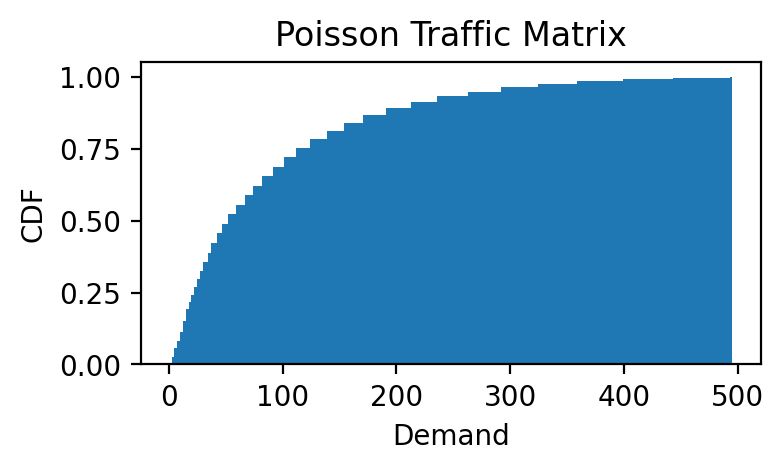

In [11]:
# Easy problems -- >80% of demand is satisfied with scale_factor=8
# Hard problems --> <80% demand satisfied with scale_factor=16
# scale_factor = 8
scale_factor = 16
# UsCarrier
# topo_name = "UsCarrier"
# topo_fname = "../topologies/UsCarrier.json"
# poisson_params = { "decay": 0.25, "lam": 3.5e6, "const_factor": 3e-5, "scale_factor" : scale_factor}
# generate_poisson_tm(topo_fname, poisson_params, topo_name)
# Kdl
topo_name = "Kdl"
topo_fname = "../topologies/Kdl.json"
poisson_params = { "decay": 0.9, "lam": 8e9, "const_factor": 4.3e-9, "scale_factor" : scale_factor}
generate_poisson_tm(topo_fname, poisson_params, topo_name)
# ASN
# topo_name = "ASN"
# topo_fname = "../topologies/ASN2k.json"
# poisson_params = { "decay": 0.15, "lam": 5e9, "const_factor": 4.3e-9, "scale_factor" : scale_factor}
# generate_poisson_tm(topo_fname, poisson_params, topo_name)

### Bimodal

In [38]:
def generate_bimodal_tm(topo_fname, bimodal_params, topo_name):
  problem = Problem.from_file(topo_fname, None)
  bimodal_tm = BimodalTrafficMatrix(problem, None, **bimodal_params)
  save_filename = f"../traffic-matrices/bimodal/{topo_name}_{bimodal_params['fraction']}_{bimodal_params['low_range']}_{bimodal_params['high_range']}_{bimodal_params['scale_factor']}.pkl"
  save_filename = save_filename.replace(" ", ":")  # remove spaces if any
  save_filename = save_filename.replace(",", "")  # remove spaces if any
  save_filename = save_filename.replace("\'", "")  # remove spaces if any
  print(f"save_filename: {save_filename}")
  pickle.dump(bimodal_tm._tm, open(save_filename, "wb"))
  total_demand = bimodal_tm.total_demand
  print("total demand: {}".format(total_demand))
  tm = bimodal_tm._tm
  _ = plt.hist(tm.flatten(), bins=200, density=True, cumulative=True)
  plt.xlabel("Demand")
  plt.ylabel("CDF")
  plt.title("Bimodal Traffic Matrix")
  plt.gcf().set_size_inches(4, 2)
  plt.gcf().set_dpi(200)

Invalidating commodity lists..
save_filename: ../traffic-matrices/bimodal/ASN_0.2_(0.02:0.04)_(0.08:0.16)_24.pkl
total demand: 3482209.980668501


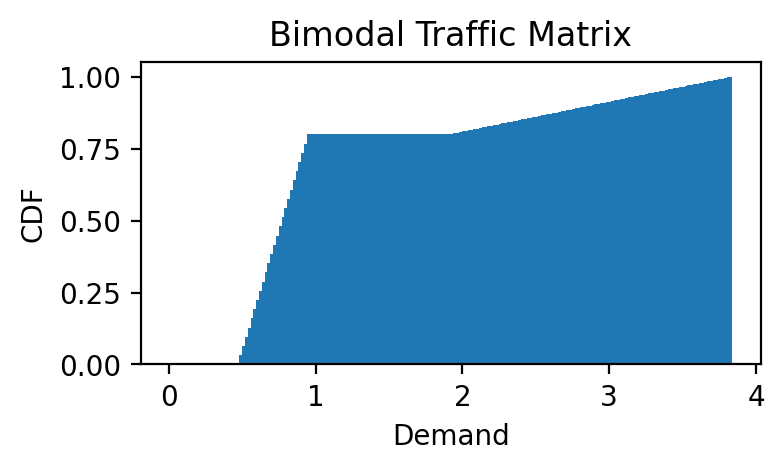

In [43]:
# Easy problems -- >80% of demand is satisfied with scale_factor=8
# Hard problems --> <80% demand satisfied with scale_factor=16
# scale_factor = 8
scale_factor = 24
# Kdl
topo_name = "Kdl"
topo_fname = "../topologies/Kdl.json"
bimodal_params = { "fraction": 0.2, "low_range": (0.02, 0.04), "high_range": (0.08, 0.16), "scale_factor" : scale_factor}
# generate_bimodal_tm(topo_fname, bimodal_params, topo_name)
# ASN
topo_name = "ASN"
topo_fname = "../topologies/ASN2k.json"
bimodal_params = { "fraction": 0.2, "low_range": (0.02, 0.04), "high_range": (0.08, 0.16), "scale_factor" : scale_factor}
# poisson_params = { "decay": 0.15, "lam": 5e9, "const_factor": 4.3e-9, "scale_factor" : scale_factor}
generate_bimodal_tm(topo_fname, bimodal_params, topo_name)

In [32]:
problem.traffic_matrix = bimodal_tm
traffic_seed = problem.traffic_matrix.seed
total_demand = problem.total_demand
print(f"# commodities: {len(problem.commodity_list)}")
print("traffic seed: {}".format(traffic_seed))
print("traffic scale factor: {}".format(problem.traffic_matrix.scale_factor))
print("traffic matrix model: {}".format(problem.traffic_matrix.model))
print("total demand: {}".format(total_demand))

NameError: name 'bimodal_tm' is not defined

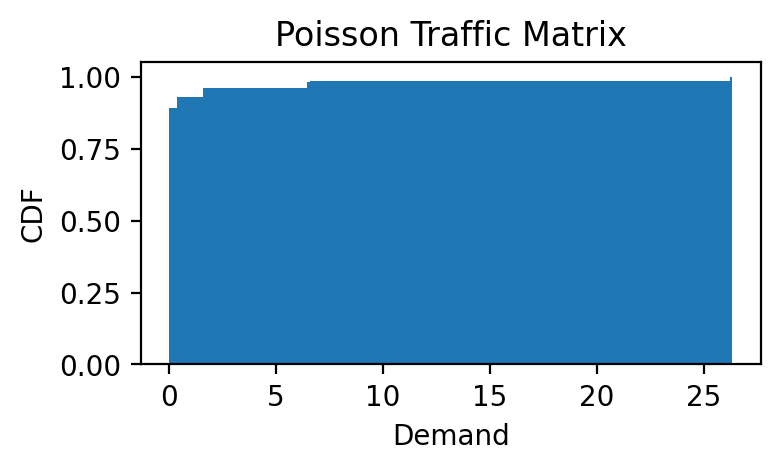

In [132]:
tm = poisson_tm._tm
_ = plt.hist(tm.flatten(), bins=200, density=True, cumulative=True)
plt.xlabel("Demand")
plt.ylabel("CDF")
plt.title("Poisson Traffic Matrix")
plt.gcf().set_size_inches(4, 2)
plt.gcf().set_dpi(200)

In [133]:
log = open("/tmp/path_formulation.txt", "w")
state = {}
pf = PathFormulationALCD(objective=Objective.get_obj_from_str("total_flow"), num_paths=num_paths,
                              edge_disjoint=edge_disjoint, dist_metric=dist_metric,out=log, VERBOSE=True)
stats, ret, state = pf.solve(problem, state=state)

t=0.00s: commodity_list extracted, size=12591
Loading paths from pickle file /home/sauce/teal/pop-ncflow-lptop/../topologies/paths/path-form/UsCarrier.json-4-paths_edge-disjoint-True_dist-metric-min-hop-dict.pkl
paths_dict size: 24806
t=0.17s: paths_dict extracted, size=24806
t=0.23s: commodities processed
Pre Solve time: 0.23s
Constructing Path LP for ALCD solver
# Paths: 20659
# Edges: 378
t=0.00s: Processed edge capacity constraints..
# Commodities: 12591
t=0.03s: Processed demand constraints..
ALCD Constraint matrix: 12969 inequalities, 0 equalities, 218050 non-zero entries
ALCD Variables: 20659 non-basic, 0 free
t=0.10s: Finished all constraints..
Construct time: 0.10s
Initalizing ALCD solver
Solving using ALCD solver
ALCD solver stats: {'primal_obj_progress': [2909547.25, 10690.59765625, -13976.3466796875, -15398.3603515625, -15400.4404296875], 'primal_inf_progress': [1.0, 1.0, 21.60008110521653, 0.2423321768196729, 0.07001619128936054], 'dual_inf_progress': [6364.053283970778, 2

In [134]:
real_tm = RealTrafficMatrix(problem, tm, None, None, 0, 1)
problem.traffic_matrix = real_tm
problem.update_traffic_matrix(1, "uniform", alpha=0.1)
traffic_seed = problem.traffic_matrix.seed
total_demand = problem.total_demand
print(f"# commodities: {len(problem.commodity_list)}")
print("traffic seed: {}".format(traffic_seed))
print("traffic scale factor: {}".format(problem.traffic_matrix.scale_factor))
print("traffic matrix model: {}".format(problem.traffic_matrix.model))
print("total demand: {}".format(total_demand))
stats, ret, state = pf.solve(problem, state=state)

Invalidating commodity lists..
Perturbing traffic matrix with uniform distribution: alpha: 0.1
Invalidating commodity lists..
Generating commodity list ...
# commodities: 12591
traffic seed: 0
traffic scale factor: 1.0
traffic matrix model: real
total demand: 15478.1533203125
t=0.00s: commodity_list extracted, size=12591
t=0.00s: commodities processed
Pre Solve time: 0.00s
Constructing Path LP for ALCD solver
# Paths: 20659
# Edges: 378
t=0.00s: Processed edge capacity constraints..
# Commodities: 12591
t=0.03s: Processed demand constraints..
ALCD Constraint matrix: 12969 inequalities, 0 equalities, 0 non-zero entries
ALCD Variables: 20659 non-basic, 0 free
Re-using Amat from previous run...
t=0.03s: Finished all constraints..
Construct time: 0.03s
Initalizing ALCD solver
Initializing x0 from previous run
Initializing w0 from previous run
Solving using ALCD solver
ALCD solver stats: {'primal_obj_progress': [15645.6552734375, -15341.275390625, -15372.435546875, -15374.123046875], 'prima

In [135]:
problem.update_traffic_matrix(1, "uniform", alpha=0.1)
traffic_seed = problem.traffic_matrix.seed
total_demand = problem.total_demand
print(f"# commodities: {len(problem.commodity_list)}")
print("traffic seed: {}".format(traffic_seed))
print("traffic scale factor: {}".format(problem.traffic_matrix.scale_factor))
print("traffic matrix model: {}".format(problem.traffic_matrix.model))
print("total demand: {}".format(total_demand))
stats, ret, state = pf.solve(problem, state=state)

Perturbing traffic matrix with uniform distribution: alpha: 0.1
Invalidating commodity lists..
Generating commodity list ...
# commodities: 12591
traffic seed: 0
traffic scale factor: 1.0
traffic matrix model: real
total demand: 15478.1318359375
t=0.00s: commodity_list extracted, size=12591
t=0.00s: commodities processed
Pre Solve time: 0.00s
Constructing Path LP for ALCD solver
# Paths: 20659
# Edges: 378
t=0.00s: Processed edge capacity constraints..
# Commodities: 12591
t=0.03s: Processed demand constraints..
ALCD Constraint matrix: 12969 inequalities, 0 equalities, 0 non-zero entries
ALCD Variables: 20659 non-basic, 0 free
Re-using Amat from previous run...
t=0.03s: Finished all constraints..
Construct time: 0.03s
Initalizing ALCD solver
Initializing x0 from previous run
Initializing w0 from previous run
Solving using ALCD solver
ALCD solver stats: {'primal_obj_progress': [15253.845703125, -15354.560546875, -15381.3896484375, -15383.0419921875], 'primal_inf_progress': [1.0, 11.8388